# CPE393 — Final Project: Predicting Airbnb Listing Prices
**Group 15** — Mathieu, Serghei, Samy

**Course:** CPE393 - Introduction to Data Science with Python  KMUTT

**Dataset:** AirBnB Listings in Major US Cities — [Kaggle link](https://www.kaggle.com/datasets/rudymizrahi/airbnb-listings-in-major-us-cities-deloitte-ml)

**Goal:** Build regression models that predict the price of an Airbnb listing (`log_price`) from property and location features. This is a **regression** problem.

## **1. Imports**

---


We import all the libraries we will use throughout the notebook. (Completed through out the development)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

import folium
from folium import plugins
from folium.plugins import MarkerCluster

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
RANDOM_STATE = 42  # fixed seed so results are reproducible

## 1. Load the datasets

In this first step, we import the two files provided for the project: `train.csv` and `test.csv`.

The training file contains the target variable `log_price`, so it is used for exploratory analysis, preprocessing, model training and validation. The test file does not contain `log_price`; it is only used at the end to generate price predictions.

The code checks several common locations, loads both files with Pandas and displays their dimensions to confirm that the import worked correctly.

In [4]:

TRAIN_PATH = None
TEST_PATH = None

for path in ['train.csv', '/content/train.csv']:   #Assigning path if the file exists
    if os.path.exists(path):
        TRAIN_PATH = path
        break
for path in ['test.csv', '/content/test.csv']:
    if os.path.exists(path):
        TEST_PATH = path
        break

if TRAIN_PATH is None:
    raise FileNotFoundError("train.csv not found.")       #Raising errors if paths are not found
if TEST_PATH is None:
    raise FileNotFoundError("test.csv not found.")


#Data importation
airbnb_train = pd.read_csv(TRAIN_PATH, engine='python', on_bad_lines='warn')
airbnb_test = pd.read_csv(TEST_PATH, engine='python', on_bad_lines='warn')

print('Training set:', airbnb_train.shape)
print('Test set:', airbnb_test.shape)

Training set: (1543, 29)
Test set: (3137, 28)


## 2. Data exploration
---
We first look at the training data to understand its structure, the column types, and possible issues.

In [5]:
# The exploratory analysis is based on the training file because it contains log_price
data = airbnb_train.copy()

print(data.head())
print()
data.info()
print()
print('Columns:', list(data.columns))

         id  log_price property_type        room_type  \
0   6901257   5.010635     Apartment  Entire home/apt   
1   6304928   5.129899     Apartment  Entire home/apt   
2   7919400   4.976734     Apartment  Entire home/apt   
3  13418779   6.620073         House  Entire home/apt   
4   3808709   4.744932     Apartment  Entire home/apt   

                                           amenities  accommodates  bathrooms  \
0  {"Wireless Internet","Air conditioning",Kitche...           3.0        1.0   
1  {"Wireless Internet","Air conditioning",Kitche...           7.0        1.0   
2  {TV,"Cable TV","Wireless Internet","Air condit...           5.0        1.0   
3  {TV,"Cable TV",Internet,"Wireless Internet",Ki...           4.0        1.0   
4  {TV,Internet,"Wireless Internet","Air conditio...           2.0        1.0   

   bed_type cancellation_policy cleaning_fee  ...   latitude   longitude  \
0  Real Bed              strict         True  ...  40.696524  -73.991617   
1  Real Bed       

Let's look at some descriptive statistics and plot a few graphs to understand the data more clearly.

                 id    log_price  accommodates    bathrooms     latitude  \
count  1.543000e+03  1543.000000   1542.000000  1537.000000  1542.000000   
mean   1.126008e+07     4.790316      3.114137     1.208848    38.503836   
std    6.215381e+06     0.717216      2.121842     0.502247     3.036840   
min    1.206800e+04     2.484907      1.000000     0.000000    33.722757   
25%    6.016475e+06     4.317488      2.000000     1.000000    34.151089   
50%    1.238868e+07     4.744932      2.000000     1.000000    40.662595   
75%    1.657608e+07     5.192957      4.000000     1.000000    40.740870   
max    2.118810e+07     7.569412     16.000000     5.000000    42.382883   

         longitude  number_of_reviews  review_scores_rating     bedrooms  \
count  1542.000000        1542.000000           1148.000000  1540.000000   
mean    -92.037717          19.418936             93.531359     1.238312   
std      21.767771          35.635651              9.604737     0.817904   
min    -122

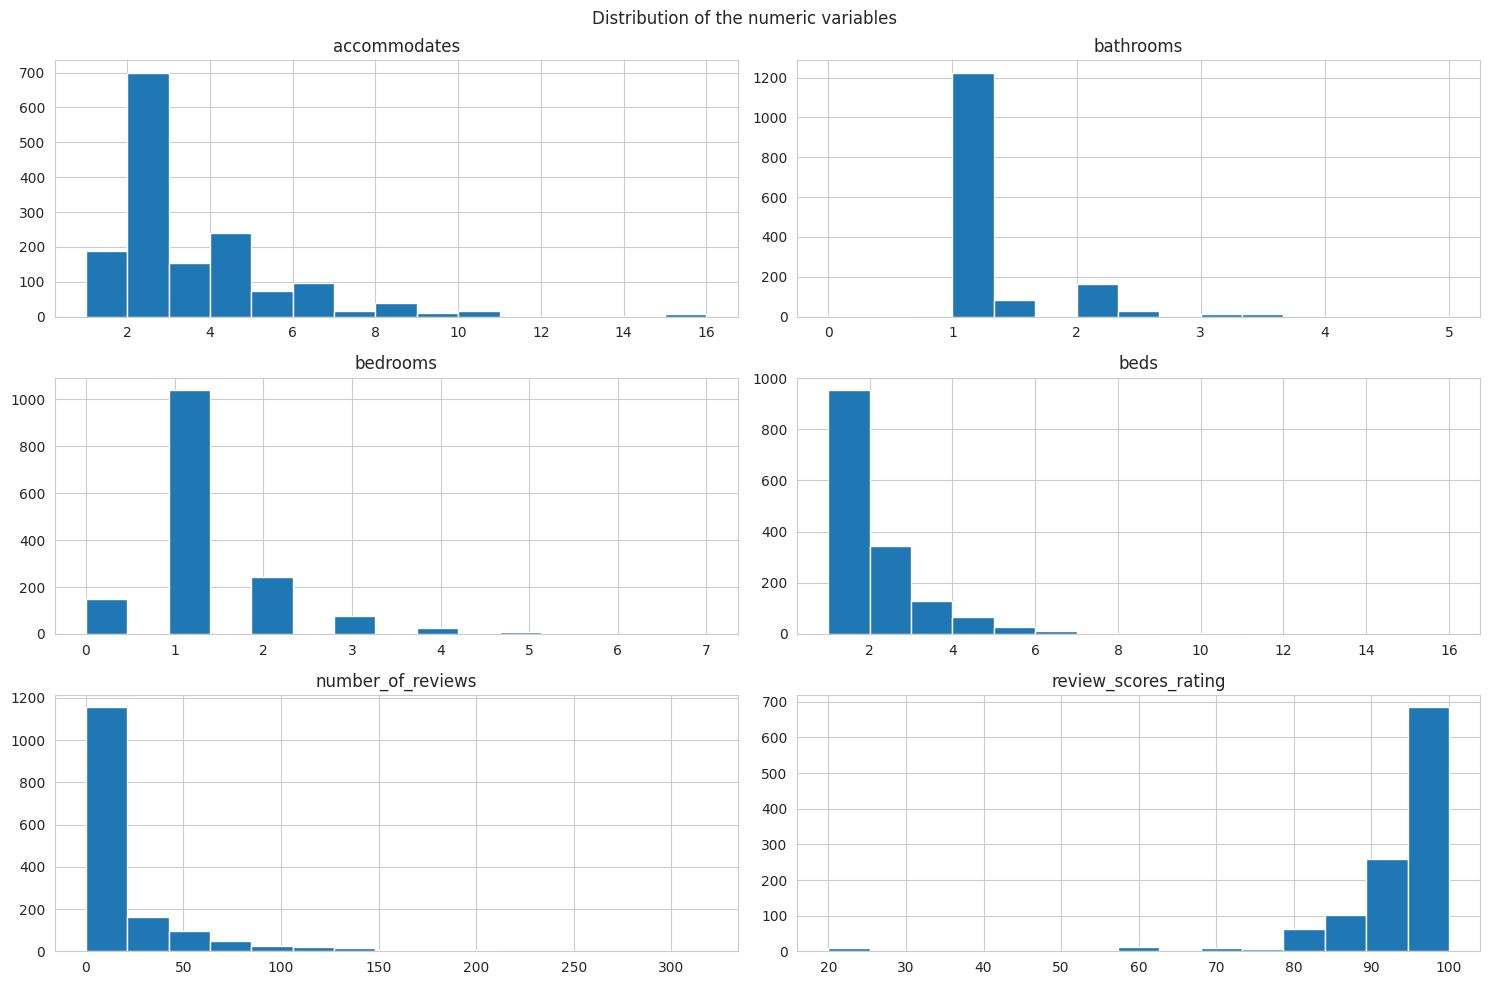

In [6]:
# Descriptive statistics of the numeric columns
print(data.describe())

# Distributions of the main numeric variables
numeric_columns = ['accommodates', 'bathrooms', 'bedrooms', 'beds',
                   'number_of_reviews', 'review_scores_rating']
data[numeric_columns].hist(bins=15, figsize=(15, 10))
plt.suptitle('Distribution of the numeric variables')
plt.tight_layout()
plt.show()

**Interpretation:**

`accommodates`, `bedrooms`, `beds` and `bathrooms` are right-skewed: most listings are small (1-2 bedrooms, capacity 2-4). `number_of_reviews` has a very long tail (a few listings with hundreds of reviews), and `review_scores_rating` is strongly concentrated near 90-100, so it will carry little discriminating power on its own.

**Let's look at the Airbnb distribution map**



In [7]:
data_sample = data.sample(500) #we take only 500 values so the process will not be too long
# Map creation
map = folium.Map(location=[data_sample['latitude'].mean(), data_sample['longitude'].mean()], zoom_start=12)

# Adding a MarkerCluster for grouping markers
marker_cluster = MarkerCluster().add_to(map)

# adding the markers on the map
for idx, row in data_sample.iterrows():
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=f'Price (log): {row["log_price"]}',
        icon=folium.Icon(color='blue', icon='info-sign')
    ).add_to(marker_cluster)

#Map showing
map.save('map.html')
map

We plot the distribution of the categorical variables to see the most common categories.

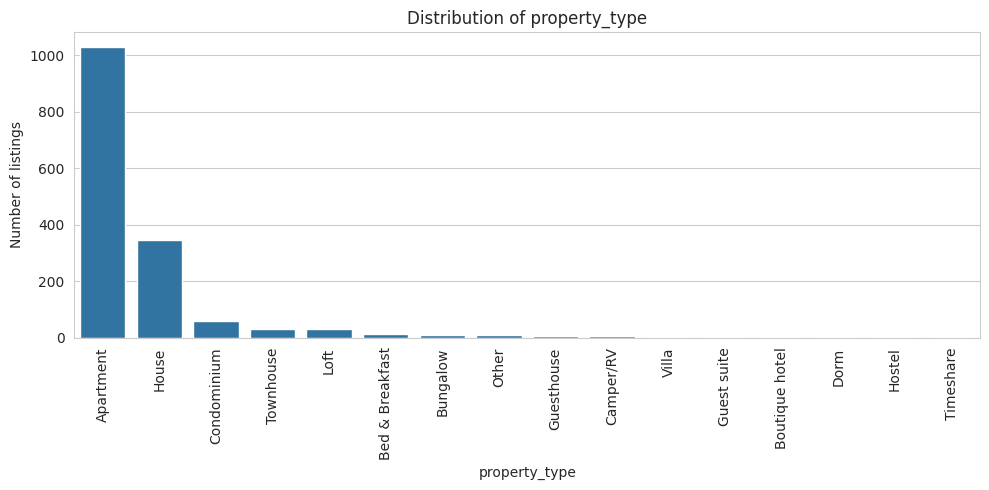

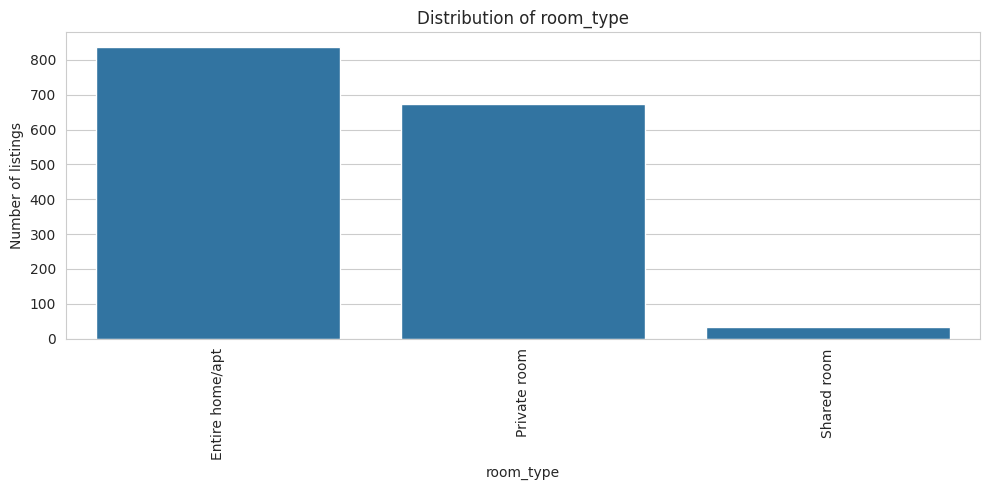

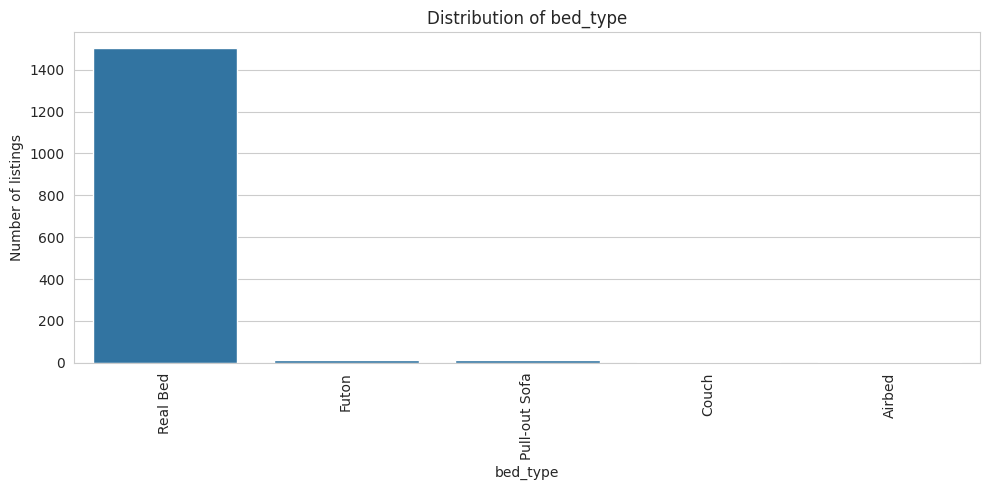

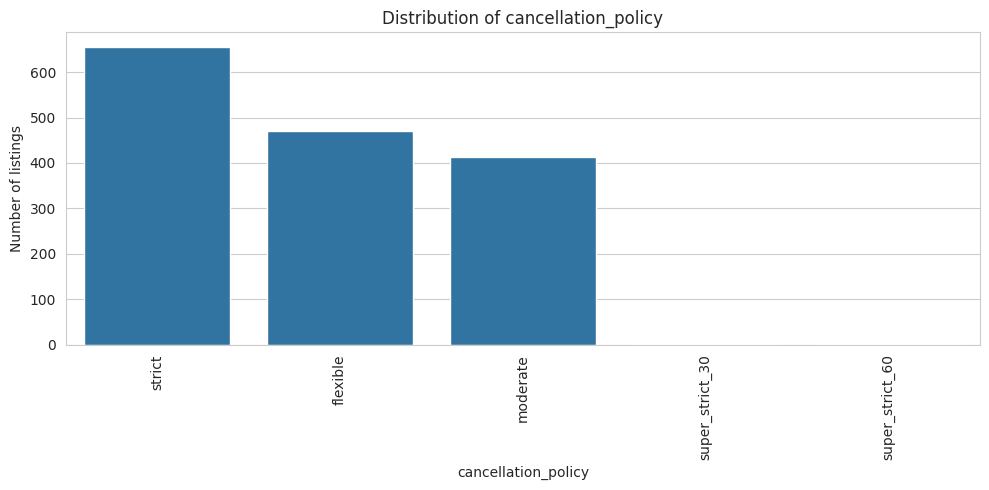

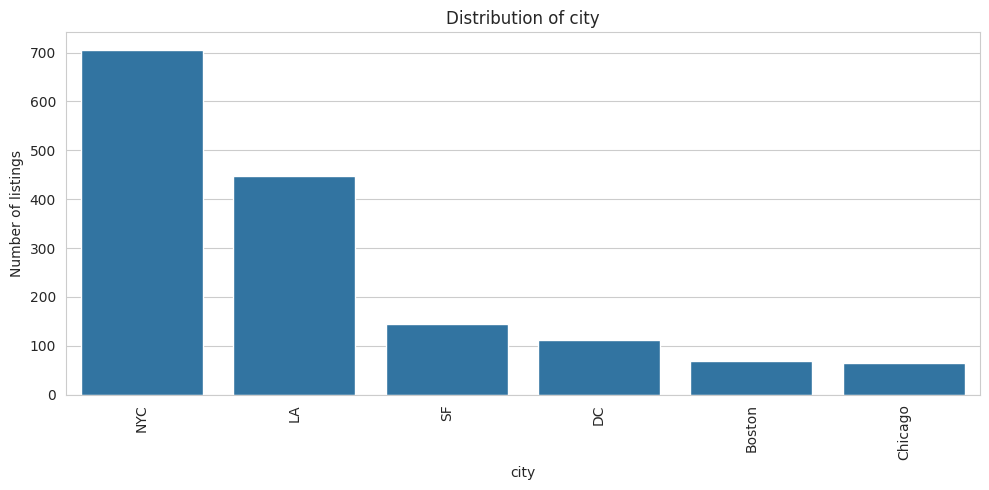

In [8]:
# Distributions of the categorical variables
categorical_columns = ['property_type', 'room_type', 'bed_type', 'cancellation_policy', 'city']

for column in categorical_columns:
    plt.figure(figsize=(10, 5))
    order = data[column].value_counts().index
    sns.countplot(data=data, x=column, order=order)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Number of listings')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

**Interpretation.** The dataset is dominated by **Apartments**, **Entire home/apt** listings and **Real Bed** / **strict** policies. **NYC (~26k)** and **LA (~18k)** make up most of the rows, while Boston and Chicago are under-represented (~3k each). This class imbalance across cities is worth keeping in mind when we interpret city-level effects.

### Target variable: `log_price``log_price` is the natural logarithm of the nightly price. The raw price is heavily right-skewed, so taking the log makes the distribution closer to normal, which helps the regression models.

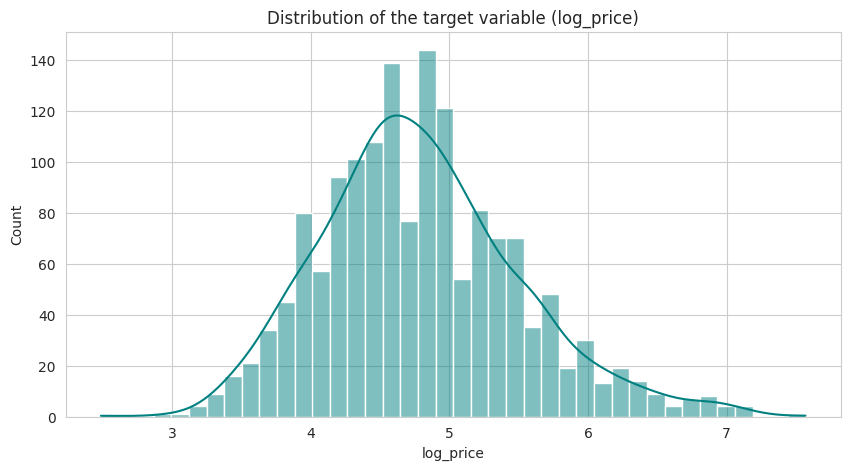

Price (log) statistics:
count    1543.000000
mean        4.790316
std         0.717216
min         2.484907
25%         4.317488
50%         4.744932
75%         5.192957
max         7.569412
Name: log_price, dtype: float64


In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(data['log_price'], kde=True, bins=40, color='teal')
plt.title('Distribution of the target variable (log_price)')
plt.xlabel('log_price')
plt.ylabel('Count')
plt.show()

print('Price (log) statistics:')
print(data['log_price'].describe())

### Price by city and room typeThese two plots show how the price changes depending on the city and the type of room. They give a first idea of which features matter for predicting the price.

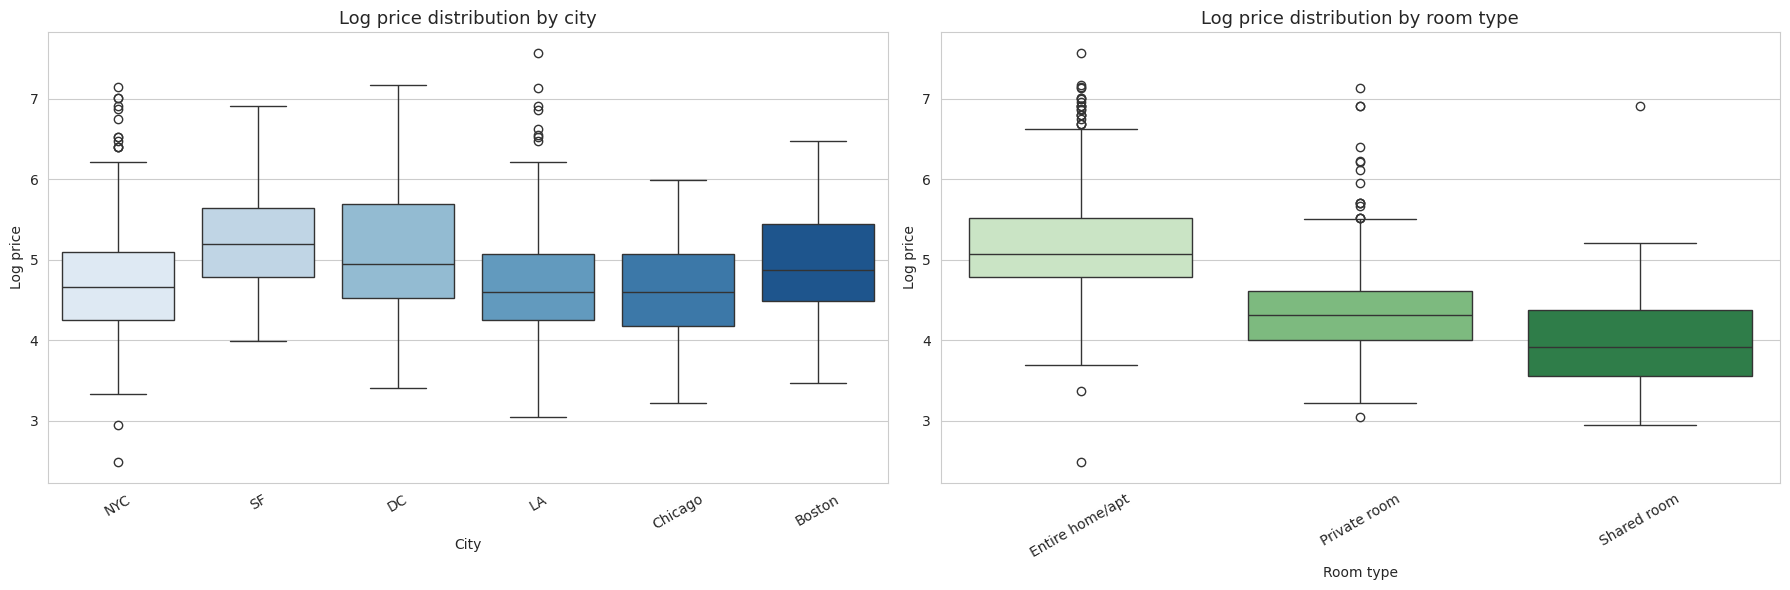

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.boxplot(data=data, x='city', y='log_price', ax=axes[0], palette='Blues')
axes[0].set_title('Log price distribution by city', fontsize=13)
axes[0].set_xlabel('City')
axes[0].set_ylabel('Log price')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=data, x='room_type', y='log_price', ax=axes[1], palette='Greens')
axes[1].set_title('Log price distribution by room type', fontsize=13)
axes[1].set_xlabel('Room type')
axes[1].set_ylabel('Log price')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**Interpretation.** Price clearly depends on both variables. **SF** and **Boston** have the highest median `log_price`, while **Chicago** is the lowest. For room type the ranking is intuitive: **Entire home/apt > Private room > Shared room**. These two categorical features already look like strong predictors, which the correlation matrix below confirms.

## 3. Preprocessing and cleaning
---
In this section we prepare the data for modeling.
1. Drop columns
that are not useful for a simple model (free text, urls, ids, dates).
2. Handle missing values.
3. Encode the categorical columns into numbers with `LabelEncoder`. We write this as a single clean function so we can apply **exactly the same steps** to the training set and to the test set (this avoids data leakage and bugs).

In [11]:
# Columns we will NOT use as features:
# - text / url / id columns that are hard to use in a simple model
# - date columns (would need extra work)
drop_columns = ['id', 'amenities', 'description', 'name', 'thumbnail_url',
                'first_review', 'last_review', 'host_since',
                'zipcode', 'neighbourhood', 'host_response_rate']

# Categorical columns we will encode into numbers
categorical_columns = ['property_type', 'room_type', 'bed_type',
                       'cancellation_policy', 'city',
                       'cleaning_fee', 'host_has_profile_pic',
                       'host_identity_verified', 'instant_bookable']

# Numeric feature columns
numeric_features = ['accommodates', 'bathrooms', 'bedrooms', 'beds',
                    'number_of_reviews', 'review_scores_rating',
                    'latitude', 'longitude']

In [12]:
def preprocess(df, encoders=None, fit=True):
    """Clean and encode the dataframe.
    If fit=True we create new LabelEncoders (training set).
    If fit=False we reuse the encoders fitted on the training set (test set).
    Returns the processed feature dataframe and the encoders.
    """
    df = df.copy()

    # 1. Drop unused columns (ignore errors if a column is missing)
    df = df.drop(columns=drop_columns, errors='ignore')

    # 2. Fill missing values
    for col in ['bathrooms', 'bedrooms', 'beds', 'review_scores_rating']:
        df[col] = df[col].fillna(df[col].median())

    # Fill missing categorical values with the string 'missing'
    for col in categorical_columns:
        df[col] = df[col].astype(str).fillna('missing')

    # 3. Encode categorical columns
    if fit:
        encoders = {}
        for col in categorical_columns:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col])
            encoders[col] = le
    else:
        for col in categorical_columns:
            le = encoders[col]
            # Map unseen categories in the test set to a safe default (0)
            df[col] = df[col].map(
                lambda v: le.transform([v])[0] if v in le.classes_ else 0
            )

    # 4. Keep only the feature columns (drop the target if present)
    feature_cols = numeric_features + categorical_columns
    df = df[feature_cols]

    return df, encoders

### Correlation heatmapAfter encoding, we can look at how each feature correlates with `log_price`. This helps us see which variables are the most useful for prediction.

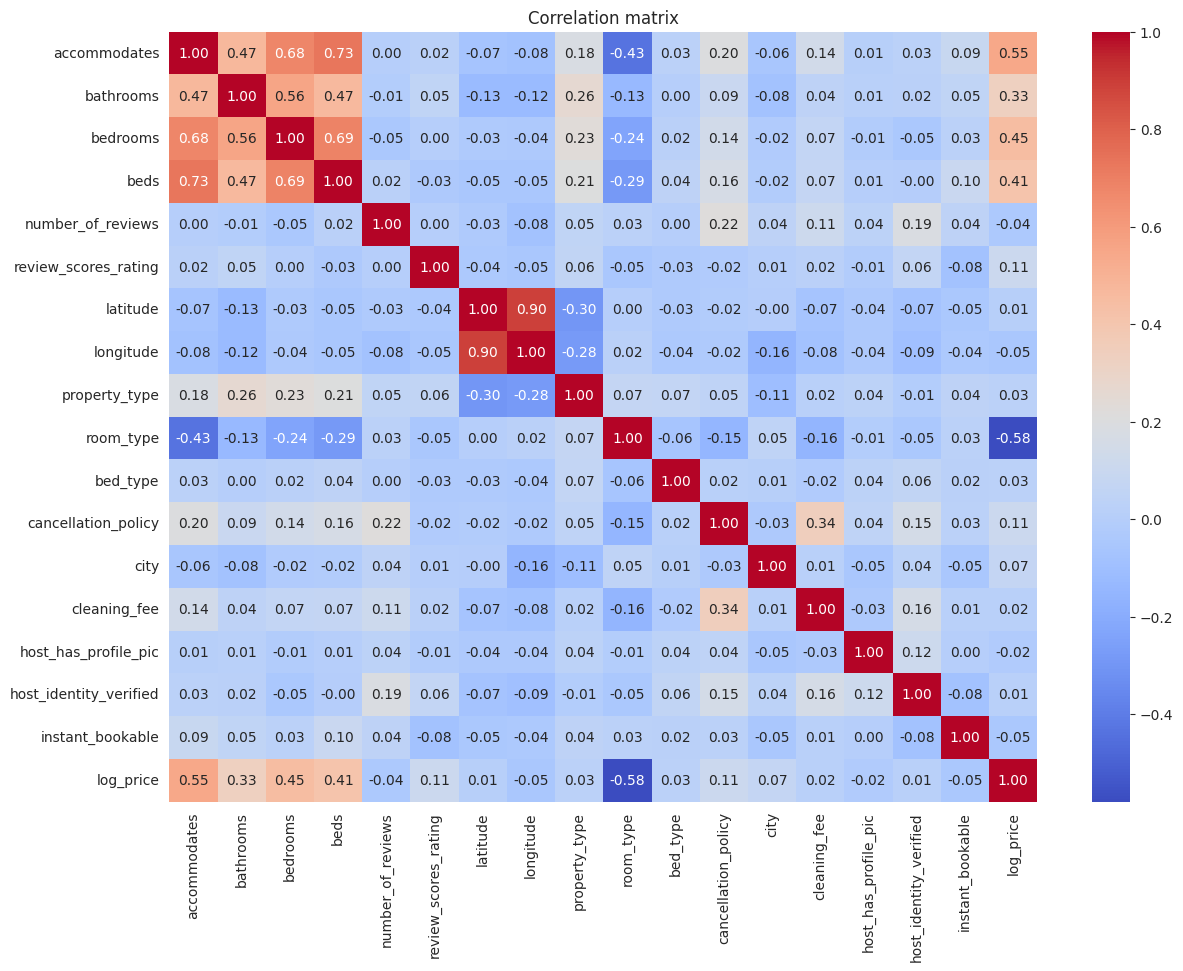

Correlation of each feature with log_price:
log_price                 1.000000
accommodates              0.545799
bedrooms                  0.445589
beds                      0.408781
bathrooms                 0.329295
cancellation_policy       0.108001
review_scores_rating      0.106087
city                      0.069791
property_type             0.027677
bed_type                  0.025529
cleaning_fee              0.016089
host_identity_verified    0.012920
latitude                  0.012207
host_has_profile_pic     -0.021644
number_of_reviews        -0.042613
instant_bookable         -0.045150
longitude                -0.052565
room_type                -0.579511
Name: log_price, dtype: float64


In [13]:
train_raw = airbnb_train
X_encoded, encoders = preprocess(train_raw, fit=True)
corr_df = X_encoded.copy()
corr_df['log_price'] = train_raw['log_price'].values

plt.figure(figsize=(14, 10))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation matrix')
plt.show()

# Features most correlated with log_price
high_corr = corr_df.corr()['log_price'].sort_values(ascending=False)
print('Correlation of each feature with log_price:')
print(high_corr)



**Interpretation.**
---
The strongest linear signals are `room_type` (**-0.61**, entire-home encoded low / shared-room high) and `accommodates` (**+0.57**), followed by `bedrooms`, `beds` and `bathrooms`. `latitude`, `longitude` and `number_of_reviews` are almost uncorrelated with price on their own, but a tree model can still exploit them through non-linear interactions.

## 4. Prepare the data for modeling

We build the feature matrix `X` and the target `y` from `airbnb_train`, which comes from `train.csv`. Then we split this training data into a training part and a validation part. This gives us a reliable way to compare models before applying the final model to `airbnb_test`. Finally, the numerical feature matrix is scaled with `StandardScaler`.

In [14]:
# Reuse the train.csv dataframe loaded at the beginning of the notebook
train_raw = airbnb_train.copy()

# Features and target
X, encoders = preprocess(train_raw, fit=True)
y = train_raw['log_price']

# Train / validation split inside the training dataset
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# Scale the features using only the training split
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print('X_train:', X_train_scaled.shape)
print('X_val:  ', X_val_scaled.shape)

X_train: (1234, 17)
X_val:   (309, 17)


## 5. Train and compare four regression models

We train four models and compare them using **MAE**, **RMSE** and **R²**:

- **Linear Regression** — simple baseline model
- **Ridge Regression** — linear model with regularization
- **Random Forest Regressor** — tree-based model that captures non-linear relationships
- **Gradient Boosting Regressor** — boosting model that builds trees sequentially to reduce prediction errors

The objective is not to select a model automatically. We compare the scores, then choose the final model manually based on both performance and interpretation.

In [15]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=200),
    'Gradient Boosting': GradientBoostingRegressor(random_state=RANDOM_STATE)
}

results = []
validation_predictions = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_val_scaled)

    mae = mean_absolute_error(y_val, preds)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    r2 = r2_score(y_val, preds)

    trained_models[name] = model
    validation_predictions[name] = preds
    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})

    print(f'{name:20s} | MAE: {mae:.3f} | RMSE: {rmse:.3f} | R2: {r2:.3f}')

results_df = pd.DataFrame(results).sort_values('RMSE')
print()
print('Summary (sorted by RMSE, lower is better):')
print(results_df.to_string(index=False))

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

**Interpretation.**


---


Linear Regression and Ridge Regression are close because they are both linear models. The difference comes from the Ridge penalty: Ridge adds regularization, which slightly shrinks the coefficients to make the model less sensitive to noisy or correlated features. If the regularization is weak and the features are standardized, the scores can be almost identical. If some features are correlated or unstable, Ridge can become slightly better or slightly worse than ordinary Linear Regression.

Random Forest and Gradient Boosting are more advanced tree-based models. They usually perform better on Airbnb price prediction because the relationship between price, city, room type, capacity and location is not purely linear.

The final model is selected manually after comparing the scores. This keeps the reasoning clear and avoids choosing a model only because it has the best number on one validation split.

### Visual comparison of the models

The bar charts compare the global performance of the models. RMSE should be as low as possible, while R² should be as high as possible.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=results_df, x='Model', y='MAE', ax=axes[0], palette='Blues')
axes[0].set_title('MAE by model (lower is better)')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(data=results_df, x='Model', y='RMSE', ax=axes[1], palette='Oranges')
axes[1].set_title('RMSE by model (lower is better)')
axes[1].tick_params(axis='x', rotation=20)

sns.barplot(data=results_df, x='Model', y='R2', ax=axes[2], palette='Greens')
axes[2].set_title('R² by model (higher is better)')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 6. Best model and validation diagnostics

After comparing the models, we choose the final model. This is important because model selection should be based on both performance and interpretation, not only on an automatic ranking.

In this version, we keep **Random Forest** as the selected model because it generally gives strong validation scores, captures non-linear relationships, and provides feature importance, which helps explain the prediction results.

Since `test.csv` does not contain the real `log_price`, the best way to visually evaluate the selected model is to use the validation split from `train.csv`, where the real values are known.

The following graphs show predictions vs real values, the distribution of real and predicted prices, and the residual errors.

In [ ]:
best_model = trained_models['Random Forest']
val_preds = validation_predictions['Random Forest']
residuals = y_val - val_preds

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Predictions vs real values
axes[0, 0].scatter(y_val, val_preds, alpha=0.25, s=12)
min_value = min(y_val.min(), val_preds.min())
max_value = max(y_val.max(), val_preds.max())
axes[0, 0].plot([min_value, max_value], [min_value, max_value], 'r--', lw=2)
axes[0, 0].set_xlabel('Real log_price')
axes[0, 0].set_ylabel('Predicted log_price')
axes[0, 0].set_title('Predictions vs real values (validation set)')

# 2. Real vs predicted distribution
sns.kdeplot(y_val, ax=axes[0, 1], label='Real', fill=True, alpha=0.35, color='green')
sns.kdeplot(val_preds, ax=axes[0, 1], label='Predicted', fill=True, alpha=0.35, color='blue')
axes[0, 1].set_xlabel('log_price')
axes[0, 1].set_title('Real vs predicted distribution')
axes[0, 1].legend()

# 3. Residual distribution
sns.histplot(residuals, kde=True, bins=40, ax=axes[1, 0], color='purple')
axes[1, 0].axvline(0, color='red', linestyle='--')
axes[1, 0].set_xlabel('Residuals (real - predicted)')
axes[1, 0].set_title('Distribution of prediction errors')

# 4. Residuals vs predicted values
axes[1, 1].scatter(val_preds, residuals, alpha=0.25, s=12)
axes[1, 1].axhline(0, color='red', linestyle='--')
axes[1, 1].set_xlabel('Predicted log_price')
axes[1, 1].set_ylabel('Residuals')
axes[1, 1].set_title('Residuals vs predicted values')

plt.tight_layout()
plt.show()

print('Validation diagnostics for Random Forest')
print(f'Mean residual: {residuals.mean():.4f}')
print(f'Residual std:  {residuals.std():.4f}')

### Feature importance
The Random Forest can tell us which features it relies on the most to predict the price.

In [ ]:
importances = pd.Series(best_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 8))
importances.plot(kind='barh')
plt.title('Feature importance (Random Forest)')
plt.xlabel('Importance')
plt.show()

**Interpretation.** The Random Forest relies mostly on **`room_type`**, **`accommodates`** and the geographic coordinates (**`longitude`**, **`latitude`**), plus `bedrooms`/`bathrooms`. This matches the EDA: capacity and location drive the price. Note that the coordinates matter much more to the tree model than their weak linear correlation suggested.

## 7. Generate predictions on `test.csv`

The official test file does not contain the target variable `log_price`. Therefore, we cannot calculate MAE, RMSE or R² on this file.

The final evaluation is done with the validation split created from `train.csv`. Then, the best model is applied to `test.csv` to generate predicted Airbnb prices.

In [ ]:
# Reuse the test.csv dataframe loaded at the beginning of the notebook
test_raw = airbnb_test.copy()

# Apply the same preprocessing as for the training data
X_test, _ = preprocess(test_raw, encoders=encoders, fit=False)

# Scale using the scaler fitted on the training data
X_test_scaled = scaler.transform(X_test)

# Generate predictions for test.csv
test_preds = best_model.predict(X_test_scaled)

print('Predictions generated for test.csv')
print('Number of predictions:', len(test_preds))

**Interpretation.**

Since `test.csv` does not contain `log_price`, we cannot calculate final test metrics. The model performance is measured on the validation split from `train.csv`. The final test file is used only to generate predictions for unseen Airbnb listings.

In [ ]:
# Save the predictions to a CSV file
output = pd.DataFrame({
    'id': test_raw['id'],
    'predicted_log_price': test_preds
})

output.to_csv('airbnb_predictions.csv', index=False)
print('Predictions saved to airbnb_predictions.csv')
print(output.head())

In [ ]:
# Distribution of the predicted prices on the official test file
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(test_preds, kde=True, color='blue', bins=40, ax=axes[0])
axes[0].set_xlabel('predicted_log_price')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of predicted prices on test.csv')

# Compare the shape of final test predictions with validation predictions
sns.kdeplot(val_preds, ax=axes[1], label='Validation predictions', fill=True, alpha=0.35, color='green')
sns.kdeplot(test_preds, ax=axes[1], label='Test predictions', fill=True, alpha=0.35, color='blue')
axes[1].set_xlabel('predicted_log_price')
axes[1].set_title('Validation predictions vs test predictions')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Responsible AIA few important points about using this model responsibly

---

**Data bias:** the dataset only covers 6 US cities and comes from 2017-2018. Prices have changed a lot since then, so the model should **not** be used to set real prices today.

**Geographic bias:** neighborhood and city strongly influence the price. A model like this could reinforce existing price differences between areas.

**Ethical use:** automated pricing tools can hurt both hosts (if the estimate is too low) and guests (if it pushes prices up). Predictions should be treated as a rough guide, not a decision.

**Honest reporting:** we report MAE, RMSE and R² on a test set the model never saw, instead of only showing the best training score. We do not claim the model is perfect.

**No personal data:** we removed free-text and host-related columns, so the model does not rely on personal information.
  
**AI tools:** we used AI assistants only for help with debugging, code explanation and grammar. We understand and can explain every step of this notebook.

## 9. Conclusion

In this project we built a complete data science pipeline to predict Airbnb listing prices:

1. We loaded the two available files, `train.csv` and `test.csv`.
2. We explored the training data through distributions, maps, boxplots and a correlation matrix.
3. We cleaned the data, handled missing values and encoded categorical features.
4. We trained and compared four regression models: Linear Regression, Ridge Regression, Random Forest and Gradient Boosting.
5. We manually selected the final model using a validation split from `train.csv`.
6. We applied the selected model to `test.csv` to generate predicted `log_price` values.

**Main finding:** the tree-based models are more suitable than simple linear models because Airbnb prices depend on non-linear relationships between room type, capacity, location and property characteristics. Random Forest is kept as the final model because it combines strong validation performance with useful interpretability through feature importance.

**Important note:** `test.csv` does not contain `log_price`, so it cannot be used to calculate final evaluation metrics. The model performance is therefore measured on the validation split created from `train.csv`.

**Future work:** use the text columns (`amenities`, `description`) with NLP, add the neighborhood back with better encoding, and tune the tree-based models' hyperparameters to improve accuracy.